# Credit Card Fraud Detection — Exploratory Data Analysis

This notebook performs EDA on the cleaned Credit Card Fraud Detection dataset.

The goal is to understand the dataset before training machine learning models.

In [3]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Define the path to the cleaned dataset
CLEANED_DATA = "../data/processed/creditcard_cleaned.csv"

# Load the cleaned dataset
df_cleaned = pd.read_csv(CLEANED_DATA)


Create EDA Copy

This helps protect the original cleaned dataset from accidental changes.

In [13]:
# Create a copy of the cleaned dataset for EDA
eda_df = df_cleaned.copy()

## 1. Basic Dataset Overview

We check the dataset size, columns, data types, and first rows.

In [6]:
# Display dataset shape
print("Dataset Shape:")
print(eda_df.shape)

# Display dataset information
print("\nDataset Information:")
eda_df.info()

# Display first rows
print("\nDataset Preview:")
display(eda_df.head())

Dataset Shape:
(283726, 31)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Missing Values and Duplicates Check

Check whether the cleaned dataset still contains missing values or duplicate records.

In [7]:
# Check missing values in each column
missing_values = eda_df.isnull().sum()

# Display missing values
print("Missing values:")
display(missing_values)

# Calculate total number of missing values
print("Total missing values:")
print(missing_values.sum())

# Check duplicate records
duplicate_count = eda_df.duplicated().sum()

# Display duplicate count
print("\nDuplicate records:")
print(duplicate_count)

Missing values:


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values:
0

Duplicate records:
0


**Result:** No missing values or duplicate records were found after the ETL process.

## 3. Class Distribution

Analyze the target variable `Class` to understand the balance between normal and fraudulent transactions.

Class counts:


Class
0    283253
1       473
Name: count, dtype: int64


Class percentages:


Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

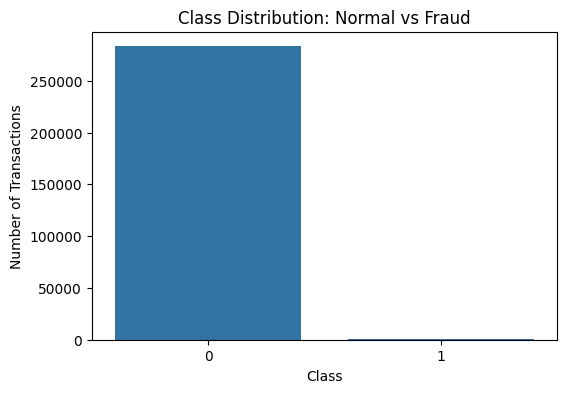

In [8]:
# Count normal and fraud transactions
class_counts = eda_df["Class"].value_counts()

# Calculate class percentages
class_percentages = round(eda_df["Class"].value_counts(normalize=True) * 100, 4)

# Display class counts
print("Class counts:")
display(class_counts)

# Display class percentages
print("\nClass percentages:")
display(class_percentages)

# Plot class distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=eda_df,
    x="Class"
)

plt.title("Class Distribution: Normal vs Fraud")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

**Result:** The dataset is highly imbalanced. Fraud transactions represent less than 1% of all transactions.

## 4. Amount Analysis

Analyze transaction amounts and compare amount patterns between normal and fraudulent transactions.

Amount summary:


count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


Amount by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


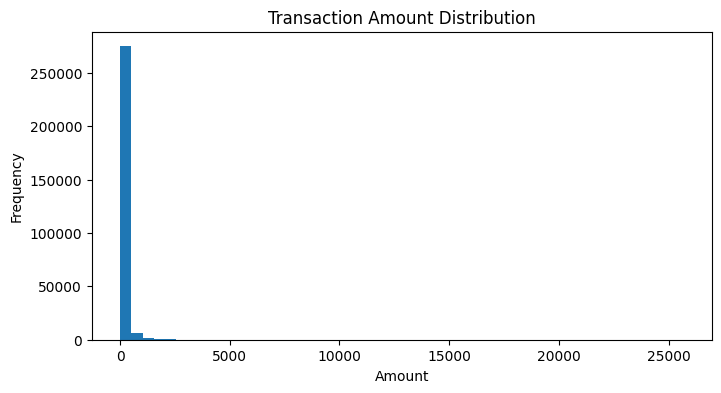

In [9]:
# Display summary statistics for transaction amount
print("Amount summary:")
display(eda_df["Amount"].describe())

# Compare amount statistics by class
print("\nAmount by class:")
amount_by_class = eda_df.groupby("Class")["Amount"].describe()
display(amount_by_class)

# Plot transaction amount distribution
plt.figure(figsize=(8, 4))

plt.hist(
    eda_df["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

**Result:** Transaction amounts vary strongly. The `Amount` feature should be scaled before Logistic Regression.

## 5. Time Analysis

Analyze the `Time` feature and compare timing patterns between normal and fraudulent transactions.

Time summary:


count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64


Time by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,94835.058093,47475.550607,0.0,54233.0,84711.0,139308.0,172792.0
1,473.0,80450.513742,48636.179973,406.0,41203.0,73408.0,129095.0,170348.0


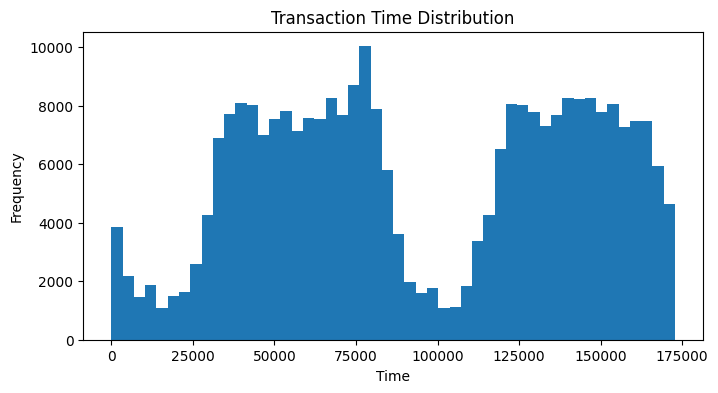

In [10]:
# Display summary statistics for Time
print("Time summary:")
display(eda_df["Time"].describe())

# Compare Time statistics by class
print("\nTime by class:")
time_by_class = eda_df.groupby("Class")["Time"].describe()
display(time_by_class)

# Plot transaction time distribution
plt.figure(figsize=(8, 4))

plt.hist(
    eda_df["Time"],
    bins=50
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

**Result:** The `Time` feature contains transaction timing information and should also be scaled before Logistic Regression.

## 6. Correlation with Fraud Target

Check which numerical features are most related to the fraud target variable.

Top positive correlations with fraud:


Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64


Top negative correlations with fraud:


V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64

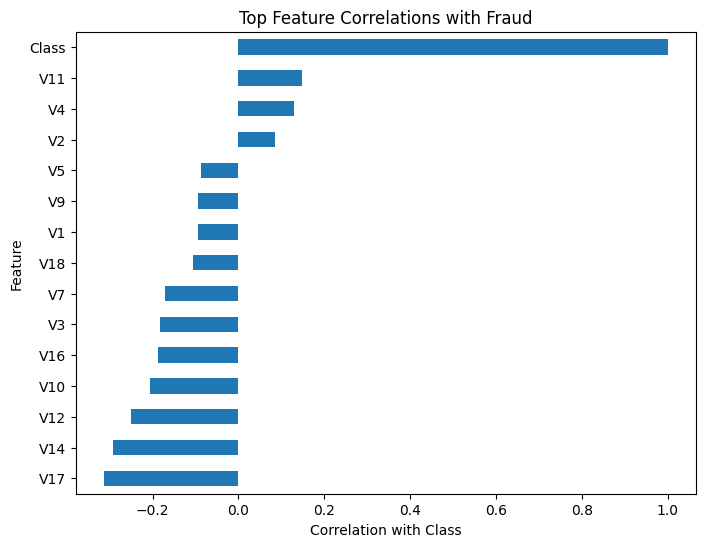

In [11]:
# Calculate correlations with the target variable
class_correlation = eda_df.corr()["Class"].sort_values(ascending=False)

# Display strongest positive correlations
print("Top positive correlations with fraud:")
display(class_correlation.head(10))

# Display strongest negative correlations
print("\nTop negative correlations with fraud:")
display(class_correlation.tail(10))

# Select strongest correlations by absolute value
top_corr_features = class_correlation.abs().sort_values(ascending=False).head(15).index

# Prepare correlation values for plotting
top_corr_values = class_correlation.loc[top_corr_features].sort_values()

# Plot strongest correlations
plt.figure(figsize=(8, 6))

top_corr_values.plot(kind="barh")

plt.title("Top Feature Correlations with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

**Result:** Some anonymized features are more related to fraud and may help the models detect fraud patterns.

## 7. EDA Summary

The EDA shows that the dataset is ready for machine learning model development.

Key findings:

- The dataset contains cleaned transaction-level fraud data.
- There are no missing values.
- There are no duplicate records after ETL.
- The target variable is highly imbalanced.
- Fraud transactions represent less than 1% of the dataset.
- `Amount` and `Time` should be scaled before Logistic Regression.
- Some anonymized features show stronger relationships with the fraud target.

Because the dataset is highly imbalanced, accuracy should not be the main evaluation metric.